In [1]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import random
from datetime import datetime
import json

import geopandas as gpd
import contextily as ctx
import io
from PIL import Image

ROOT = ".." # Adjust to repository root
CSV_DIR = os.path.join(ROOT, "csv")
os.makedirs(CSV_DIR, exist_ok=True)
PKL_DIR = os.path.join(ROOT, "pkl")
os.makedirs(PKL_DIR, exist_ok=True)
MAPS_DIR = os.path.join(ROOT, "maps")
os.makedirs(MAPS_DIR, exist_ok=True)
JSON_DIR = os.path.join(ROOT, "json")
os.makedirs(JSON_DIR, exist_ok=True)

from dotenv import load_dotenv
DOTENV_PATH = os.path.join(ROOT,"../../apis/.env") # Adjust to .env file location

if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

/home/david/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Loaded .env from /home/***/apis/.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


## AEMET OpenData

* Documentation: https://opendata.aemet.es/centrodedescargas/AEMETApi
* Obtaining an API key: https://opendata.aemet.es/centrodedescargas/altaUsuario

## Helper functions

In [2]:
BASE_URL = "https://opendata.aemet.es/opendata/api"
HEADERS = {"api_key": API_KEY}

def _get_data_url(endpoint: str, params: dict | None = None) -> str | None:
    resp = requests.get(f"{BASE_URL}/{endpoint}", headers=HEADERS, params=params)
    resp.raise_for_status()
    payload = resp.json()
    return payload.get("datos")

def _download_json(url: str):
    resp = requests.get(url)
    resp.raise_for_status()
    return resp.json()

def fetch_metadata(endpoint: str) -> tuple[dict, pd.DataFrame]:
    response = requests.get(f"{BASE_URL}/{endpoint}", headers=HEADERS)
    response.raise_for_status()
    meta_url = response.json().get("metadatos")
    if not meta_url:
        return {}, pd.DataFrame()
    metadata = _download_json(meta_url)
    return metadata

def fetch_station_history(idema: str, start_date: str, end_date: str):
    date_format = "%Y-%m-%d"
    for label, value in (("start_date", start_date), ("end_date", end_date)):
        try:
            datetime.strptime(value, date_format)
        except ValueError as exc:
            raise ValueError(f"{label} must use 'YYYY-MM-DD' format.") from exc

    endpoint = (
        f"{BASE_URL}/valores/climatologicos/diarios/datos/fechaini/"
        f"{start_date}T00:00:00UTC/fechafin/{end_date}T00:00:00UTC/estacion/{idema}"
    )
    meta_resp = requests.get(endpoint, headers=HEADERS)
    meta_resp.raise_for_status()
    datos_url = meta_resp.json().get("datos")
    if not datos_url:
        raise ValueError("No datos URL returned by API")

    datos_resp = requests.get(datos_url)
    datos_resp.raise_for_status()
    return datos_resp.json()

## Current observations for all stations

Fetching from API endpoint:

In [3]:
datos_url = _get_data_url("observacion/convencional/todas")
observations = _download_json(datos_url)

print(len(observations), " observations fetched. Sample:")
print(observations[random.randint(0, len(observations)-1)])

10197  observations fetched. Sample:
{'idema': '6155A', 'lon': -4.482307, 'fint': '2026-05-19T13:00:00+0000', 'prec': 0.0, 'alt': 6.54, 'vmax': 8.8, 'vv': 5.4, 'dv': 150.0, 'lat': 36.666118, 'dmax': 150.0, 'ubi': 'MÁLAGA/AEROPUERTO', 'pres': 1019.8, 'hr': 42.0, 'stdvv': 0.6, 'ts': 33.1, 'pres_nmar': 1020.6, 'tamin': 25.0, 'ta': 26.1, 'tamax': 26.3, 'tpr': 12.2, 'stddv': 6.0, 'inso': 60.0}


In [4]:
current_observations_df = pd.DataFrame(observations)
timestamp = datetime.now().strftime("%Y%m%d-%H%M")
current_observations_df.to_csv(os.path.join(CSV_DIR, f"observations_{timestamp}.csv"), index=False)
print(f"Current observations saved to CSV with timestamp: {timestamp}")

Current observations saved to CSV with timestamp: 20260519-2037


### Update locations dictionary:

In [4]:
idema_ubi = {entry.get("idema"): entry.get("ubi") for entry in observations if entry.get("idema")}
output_path = os.path.join(JSON_DIR, "locations.json")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(idema_ubi, f, ensure_ascii=False, indent=2)

print(f"Locations map saved to: {output_path}")

Locations map saved to: ..\json\locations.json


## Sampled map view

Field info:

In [5]:
metadata_response = fetch_metadata("observacion/convencional/todas")
print(metadata_response.get('copyright'))
field_ids = [entry.get("id") for entry in metadata_response.get("campos", []) if entry.get("id")]
print(field_ids)

© AEMET. Autorizado el uso de la información y su reproducción citando a AEMET como autora de la misma.
['idema', 'lon', 'lat', 'alt', 'ubi', 'fint', 'prec', 'pacutp', 'pliqtp', 'psolt', 'vmax', 'vv', 'vmaxu', 'vvu', 'dv', 'dvu', 'dmax', 'dmaxu', 'stdvv', 'stddv', 'stdvvu', 'stddvu', 'hr', 'inso', 'pres', 'pres_nmar', 'ts', 'tss20cm', 'tss5cm', 'ta', 'tpr', 'tamin', 'tamax', 'vis', 'geo700', 'geo850', 'geo925', 'rviento', 'nieve']


In [6]:
fields_info = metadata_response.get("campos", [])
main_fields = ['idema','fint', 'ubi', 'lon', 'lat', 'prec', 'ta', 'dmax', 'hr']
candidates_name = ("nombre", "id", "campo")
candidates_desc = ("descripcion", "descripcionCampo")

for field in main_fields:
    item = next(
        (entry for entry in fields_info if any(entry.get(col) == field for col in candidates_name)),None,)
    description = (
        next((item.get(col) for col in candidates_desc if item.get(col)), None)
        if item
        else None
    )
    print(f"{field}: {description or 'Descripción no disponible'}")

idema: Indicativo climatógico de la estación meteorológia automática
fint: Fecha hora final del período de observación, se trata de datos del periodo de la hora anterior a la indicada por este campo (hora UTC)
ubi: Ubicación de la estación. Nombre de la estación
lon: Longitud de la estación meteorológica (grados)
lat: Latitud de la estación meteorológica (grados)
prec: Precipitación acumulada, medida por el pluviómetro, durante los 60 minutos anteriores a la hora indicada por el período de observación 'fint' (mm, equivalente a l/m2)
ta: Temperatura instantánea del aire correspondiente a la fecha dada por 'fint' (grados Celsius)
dmax: Dirección del viento máximo registrado en los 60 minutos anteriores a la hora indicada por 'fint' (grados)
hr: Humedad relativa instantánea del aire correspondiente a la fecha dada por 'fint' (%)


In [7]:
N_OBS = 600
observations_df = pd.DataFrame(observations)
today_date = datetime.now().strftime("%Y%m%d")
observations_df.to_csv(os.path.join(CSV_DIR, f"current_observations_{today_date}.csv"), index=False)
fint_dt = pd.to_datetime(observations_df["fint"], errors="coerce")
observations_df.loc[fint_dt.notna(), "fint"] = fint_dt.dt.strftime("%Y-%m-%dT%Hh")
print("Sample observations:")
sample_df = observations_df[main_fields].sample(N_OBS).sort_values("lat", ascending=False)
sample_df.to_pickle(os.path.join(PKL_DIR, f"sample_observations_{today_date}.pkl"))

# pd.options.display.float_format = '{:.2f}'.format
display(sample_df.head(10).style.hide(axis="index").format(precision=2))
# pd.reset_option("display.float_format")

Sample observations:


idema,fint,ubi,lon,lat,prec,ta,dmax,hr
1351,2026-05-19T18h,ESTACA DE BARES,-7.68,43.79,0.00,16.40,261.00,80.00
1208H,2026-05-19T07h,GIJÓN MUSEL,-5.70,43.56,0.00,16.90,224.00,76.00
1208H,2026-05-19T16h,GIJÓN MUSEL,-5.70,43.56,0.00,17.80,25.00,79.00
1208H,2026-05-19T15h,GIJÓN MUSEL,-5.70,43.56,0.00,18.40,59.00,80.00
1342X,2026-05-19T11h,RIBADEO VILAFRAMIL,-7.08,43.54,0.00,20.80,217.00,73.00
1207U,2026-05-19T13h,GIJÓN-CAMPUS,-5.62,43.52,0.00,18.10,338.00,80.00
1111X,2026-05-19T09h,SANTANDER CMT,-3.80,43.49,0.00,20.90,165.00,60.00
1327A,2026-05-19T11h,ONETA,-6.67,43.47,0.00,nan,257.00,nan
1363X,2026-05-19T16h,AS PONTES A AEROSA,-7.86,43.45,0.00,19.60,nan,60.00
1363X,2026-05-19T12h,AS PONTES A AEROSA,-7.86,43.45,0.00,17.20,nan,81.00


Map view:

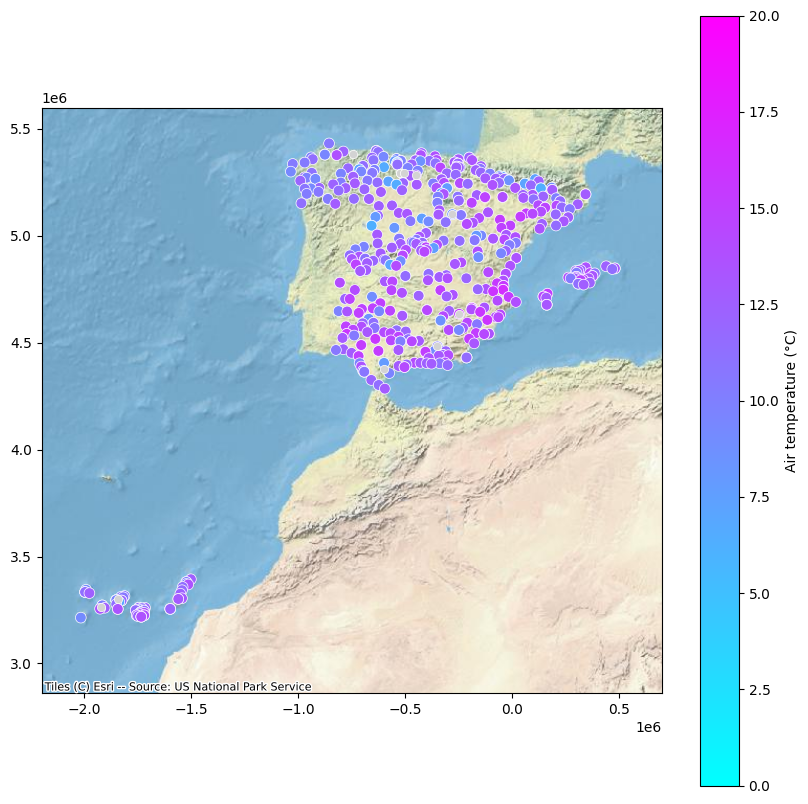

In [8]:
gdf = gpd.read_file(os.path.join(MAPS_DIR, "ne_110m_admin_0_countries.gpkg"))
sample_locations = sample_df.copy()

sample_points = gpd.GeoDataFrame(
    sample_locations.copy(),
    geometry=gpd.points_from_xy(sample_locations["lon"], sample_locations["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

sample_points.plot(
    ax=ax,
    column='ta',
    cmap='cool',
    vmin=-10,
    vmax=40,
    markersize=60,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-2200000, 700000])
ax.set_ylim([2860000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=20), cmap='cool')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Air temperature (°C)")

plt.show()

## Daily climatological values for a station

In [38]:
# IDEMA_EXAMPLE = "1167B"
IDEMA_EXAMPLE = "0367"
FEC_INI = "2021-01-01"
n_dias = 177  # each query supports approximately 6 months of data
FEC_FIN = (datetime.strptime(FEC_INI, "%Y-%m-%d") + pd.Timedelta(days=n_dias)).strftime("%Y-%m-%d")
data = fetch_station_history(IDEMA_EXAMPLE, FEC_INI, FEC_FIN)
print(len(data))
display(pd.DataFrame(data).head(5))
print("...")
display(pd.DataFrame(data).tail(5))

178


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2021-01-01,0367,GIRONA AEROPUERTO,GIRONA,143,"5,0","0,0","0,2",05:05,"9,8",...,"0,7","990,0",Varias,"987,5",14,71,97,Varias,49,15:47
1,2021-01-02,0367,GIRONA AEROPUERTO,GIRONA,143,"2,6","0,0","-2,0",Varias,"7,3",...,"0,0","992,7",Varias,"988,0",05,82,98,Varias,64,17:13
2,2021-01-03,0367,GIRONA AEROPUERTO,GIRONA,143,"2,7","0,0","-3,7",23:45,"9,1",...,"7,7","995,1",Varias,"992,5",00,70,94,Varias,43,12:17
3,2021-01-04,0367,GIRONA AEROPUERTO,GIRONA,143,"2,6","0,0","-4,9",Varias,"10,0",...,"7,8","994,7",00,"990,5",14,75,97,Varias,43,14:26
4,2021-01-05,0367,GIRONA AEROPUERTO,GIRONA,143,"3,8","0,0","-1,7",Varias,"9,2",...,"6,4","996,3",Varias,"992,7",04,71,97,Varias,44,12:56


...


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,sol,presMax,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
173,2021-06-23,0367,GIRONA AEROPUERTO,GIRONA,143,"21,0","0,2","13,9",03:19,"28,2",...,"4,0","1003,4",Varias,"999,4",02,54,93,Varias,38,13:32
174,2021-06-24,0367,GIRONA AEROPUERTO,GIRONA,143,"20,6","0,0","13,0",04:22,"28,1",...,"11,2","1006,7",Varias,"1002,9",03,57,94,Varias,32,09:56
175,2021-06-25,0367,GIRONA AEROPUERTO,GIRONA,143,"20,6","0,0","13,1",04:11,"28,1",...,"13,8","1006,4",00,"1001,3",17,59,96,Varias,43,10:08
176,2021-06-26,0367,GIRONA AEROPUERTO,GIRONA,143,"23,6","0,0","15,5",02:22,"31,7",...,"11,3","1002,7",00,"996,7",18,51,96,Varias,33,14:27
177,2021-06-27,0367,GIRONA AEROPUERTO,GIRONA,143,"24,8","0,0","17,8",23:53,"31,8",...,"12,7","998,3",01,"996,0",17,41,77,Varias,17,11:06


## Forecasts

In [17]:
municipalities_url = _get_data_url("maestro/municipios")
municipalities_data = _download_json(municipalities_url)
postal_codes = sorted({
    entry.get("id") or entry.get("idMunicipio")
    for entry in municipalities_data
    if entry.get("id") or entry.get("idMunicipio")
})
print("Total locations:", len(postal_codes))
print(",".join(postal_codes[:20]),"...")

Total locations: 8122
id01001,id01002,id01003,id01004,id01006,id01008,id01009,id01010,id01011,id01013,id01014,id01016,id01017,id01018,id01019,id01020,id01021,id01022,id01023,id01027 ...


In [18]:
postal_code = "28170"  # Valdepiélagos

endpoint = f"prediccion/especifica/municipio/diaria/{postal_code}"

datos_url = _get_data_url(endpoint)
forecast = _download_json(datos_url)

forecast[0]["prediccion"]["dia"][0]

{'probPrecipitacion': [{'value': 0, 'periodo': '00-24'},
  {'value': 0, 'periodo': '00-12'},
  {'value': 65, 'periodo': '12-24'},
  {'value': 0, 'periodo': '00-06'},
  {'value': 0, 'periodo': '06-12'},
  {'value': 0, 'periodo': '12-18'},
  {'value': 65, 'periodo': '18-24'}],
 'cotaNieveProv': [{'value': '', 'periodo': '00-24'},
  {'value': '', 'periodo': '00-12'},
  {'value': '1500', 'periodo': '12-24'},
  {'value': '', 'periodo': '00-06'},
  {'value': '', 'periodo': '06-12'},
  {'value': '', 'periodo': '12-18'},
  {'value': '1600', 'periodo': '18-24'}],
 'estadoCielo': [{'value': '', 'periodo': '00-24', 'descripcion': ''},
  {'value': '', 'periodo': '00-12', 'descripcion': ''},
  {'value': '45',
   'periodo': '12-24',
   'descripcion': 'Muy nuboso con lluvia escasa'},
  {'value': '', 'periodo': '00-06', 'descripcion': ''},
  {'value': '14', 'periodo': '06-12', 'descripcion': 'Nuboso'},
  {'value': '15', 'periodo': '12-18', 'descripcion': 'Muy nuboso'},
  {'value': '46n',
   'periodo':

## Other queries

### Map

Data URL: https://opendata.aemet.es/opendata/sh/4356716b


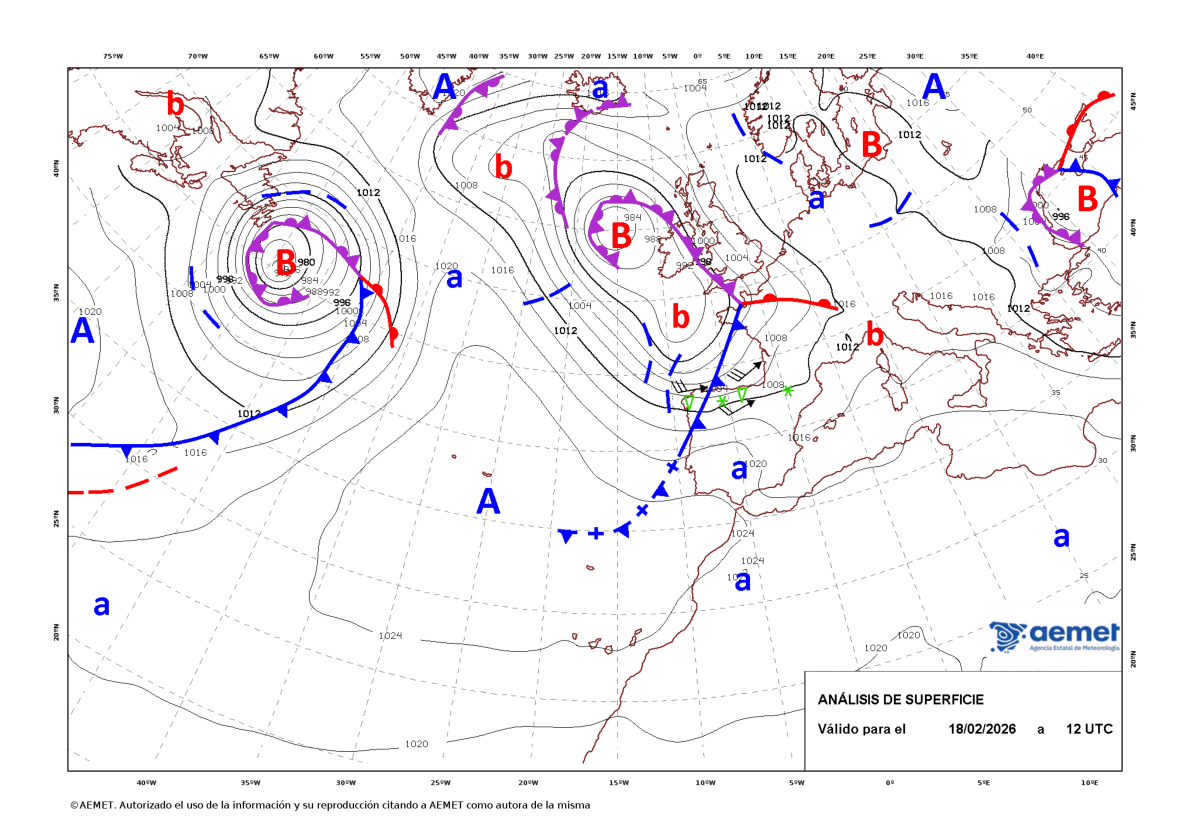

In [ ]:
QUERY = "mapasygraficos/analisis"

datos_url = _get_data_url(QUERY)
print("URL:", datos_url)

response = requests.get(datos_url)
response.raise_for_status()

img = Image.open(io.BytesIO(response.content))
img = img.rotate(-90, expand=True)
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Municipalities master

In [20]:
QUERY = "maestro/municipios"

datos_url = _get_data_url(QUERY)
json_data = _download_json(datos_url)

print(len(json_data))
print(json_data[random.randint(0, len(json_data)-1)])
display(pd.DataFrame(json_data).head(5))

8122
{'latitud': '42º18\'43.696188"', 'id_old': '17472', 'url': 'pardines-id17125', 'latitud_dec': '42.31213783', 'altitud': '1228', 'capital': 'Pardines', 'num_hab': '155', 'zona_comarcal': '691701', 'destacada': '0', 'nombre': 'Pardines', 'longitud_dec': '2.21394337', 'id': 'id17125', 'longitud': '2º12\'50.196132"'}


,latitud,id_old,url,latitud_dec,altitud,capital,num_hab,zona_comarcal,destacada,nombre,longitud_dec,id,longitud
0,"40º32'54.450744""",44004,ababuj-id44001,40.54845854,1372,Ababuj,65,624401,0,Ababuj,-0.80780117,id44001,"-0º48'28.084212"""
1,"40º54'58.824504""",40004,abades-id40001,40.91634014,971,Abades,873,674001,0,Abades,-4.26787389,id40001,"-4º16'4.346004"""
2,"43º8'51.525564""",48010,abadino-abadino-zelaieta-id48001,43.14764599,144,Abadiño-Zelaieta,7504,754802,0,Abadiño,-2.60687319,id48001,"-2º36'24.743484"""
3,"40º15'34.315272""",10004,abadia-id10001,40.25953202,451,Abadía,324,701001,0,Abadía,-5.97785806,id10001,"-5º58'40.289016"""
4,"43º21'46.874736""",27010,abadin-abadin-o-provecende-id27001,43.36302076,515,Abadín o Provecende,2646,712702,0,Abadín,-7.47214495,id27001,"-7º28'19.72182"""


In [21]:
pd.DataFrame(json_data).to_csv(os.path.join(CSV_DIR, f"maestro_municipios.csv"), index=False)

### All current observations

In [ ]:
QUERY = "observacion/convencional/todas"

datos_url = _get_data_url(QUERY)
json_data = _download_json(datos_url)

print(len(json_data))
print(json_data[random.randint(0, len(json_data)-1)])
display(pd.DataFrame(json_data).head(5))

10095
{'idema': '5726X', 'lon': -5.81917, 'fint': '2026-02-09T14:00:00+0000', 'prec': 0.8, 'alt': 720.0, 'vmax': 8.3, 'vv': 3.8, 'dv': 237.0, 'lat': 38.099445, 'dmax': 250.0, 'ubi': 'GUADALCANAL  CRISTO', 'hr': 100.0, 'tamin': 12.2, 'ta': 12.2, 'tamax': 12.4}


,idema,lon,fint,prec,alt,vmax,vv,dv,lat,dmax,...,pacutp,vvu,stdvvu,stddvu,dmaxu,tss20cm,geo925,geo850,nieve,geo700
0,0009X,0.963335,2026-02-09T03:00:00+0000,0.0,406.0,9.1,3.7,272.0,41.213892,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0016A,1.163611,2026-02-09T03:00:00+0000,0.0,71.0,6.7,4.5,250.0,41.145000,230.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0034X,1.260838,2026-02-09T03:00:00+0000,0.0,233.0,NaN,NaN,NaN,41.293053,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0042Y,1.249167,2026-02-09T03:00:00+0000,0.0,55.0,4.3,1.3,294.0,41.123892,280.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0061X,1.519269,2026-02-09T03:00:00+0000,0.0,632.0,6.2,0.7,170.0,41.417052,285.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Monthly data

In [22]:
anioIniStr = "2020"
anioFinStr = "2023"
idema = "1167B"
QUERY = f"valores/climatologicos/mensualesanuales/datos/anioini/{anioIniStr}/aniofin/{anioFinStr}/estacion/{idema}"

datos_url = _get_data_url(QUERY)
json_data = _download_json(datos_url)

print(len(json_data))
print(json_data[random.randint(0, len(json_data)-1)])
display(pd.DataFrame(json_data).head(5))
print("...")
display(pd.DataFrame(json_data).tail(5))

52
{'indicativo': '1167B', 'p_max': '21.4(09)', 'hr': '79', 'nw_55': '0', 'tm_min': '10.0', 'ta_max': '28.8(06)', 'ts_min': '15.9', 'nt_30': '0', 'w_racha': '32/11.1(07)', 'np_100': '4', 'nw_91': '0', 'np_001': '19', 'ta_min': '4.8(19)', 'w_rec': '55', 'e': '129', 'np_300': '0', 'p_mes': '102.4', 'w_med': '2', 'nt_00': '0', 'ti_max': '10.9', 'tm_mes': '15.1', 'tm_max': '20.1', 'np_010': '13', 'fecha': '2021-9'}


,indicativo,p_max,hr,nw_55,tm_min,ta_max,ts_min,nt_30,w_racha,np_100,...,w_med,nt_00,ti_max,tm_mes,tm_max,np_010,fecha,n_cub,n_des,n_nub
0,1167B,68.4(20),78,2,5.6,21.9(30),11.4,0,30/16.4(02),8,...,5,0,7.1,10.0,14.4,17,2020-10,NaN,NaN,NaN
1,1167B,NaN,79,2,0.7,15.6(21),9.5,0,33/16.1(11),NaN,...,5,15,1.3,4.1,7.5,NaN,2020-12,NaN,NaN,NaN
2,1167B,16.6(02),70,0,5.7,20.9(02),13.8,0,06/13.3(15),2,...,4,0,5.1,10.0,14.3,8,2020-11,NaN,NaN,NaN
3,1167B,31.2(29),65,1,1.7,17.9(05),6.9,0,18/15.8(19),NaN,...,4,10,-0.2,5.8,9.8,NaN,2020-1,NaN,NaN,NaN
4,1167B,NaN,74,7,6.1,33.8(07/ago),16.5,9,10/16.9(02/mar),NaN,...,4,38,-0.2,11.2,16.3,NaN,2020-13,NaN,NaN,NaN


...


,indicativo,p_max,hr,nw_55,tm_min,ta_max,ts_min,nt_30,w_racha,np_100,...,w_med,nt_00,ti_max,tm_mes,tm_max,np_010,fecha,n_cub,n_des,n_nub
47,1167B,16.0(25),74,0,5.7,26.3(03),9.8,0,26/9.2(09),3,...,3,0,9.5,11.4,17.2,12,2023-5,24,0,7
48,1167B,13.4(16),81,0,10.8,29.6(24),14.9,0,08/8.9(09),1,...,3,0,16.1,16.5,22.1,14,2023-6,21,1,8
49,1167B,9.2(12),77,0,11.4,29.0(14),14.1,0,31/8.9(08),0,...,3,0,17.9,17.6,23.7,7,2023-7,15,2,14
50,1167B,7.2(27),69,0,12.1,36.5(23),17.7,8,33/12.5(03),0,...,3,0,13.3,18.9,25.6,8,2023-8,10,3,18
51,1167B,29.4(12),68,0,11.1,30.9(30),16.0,1,20/14.2(27),1,...,3,0,14.6,17.2,23.2,13,2023-9,11,3,16
